# Verificación de Formatos (YOLO y COCO)
Este cuaderno te permite verificar visualmente que los bounding boxes hayan sido convertidos correctamente a los dos formatos estándar: **YOLO** (.txt con coordenadas relativas) y **COCO** (.json con coordenadas absolutas).

In [1]:
import cv2
import matplotlib.pyplot as plt
import os
import json
import random

## 1. Verificación del Formato YOLO
Formato esperado en el `.txt`: `clase x_centro y_centro ancho alto` (valores normalizados de 0 a 1).

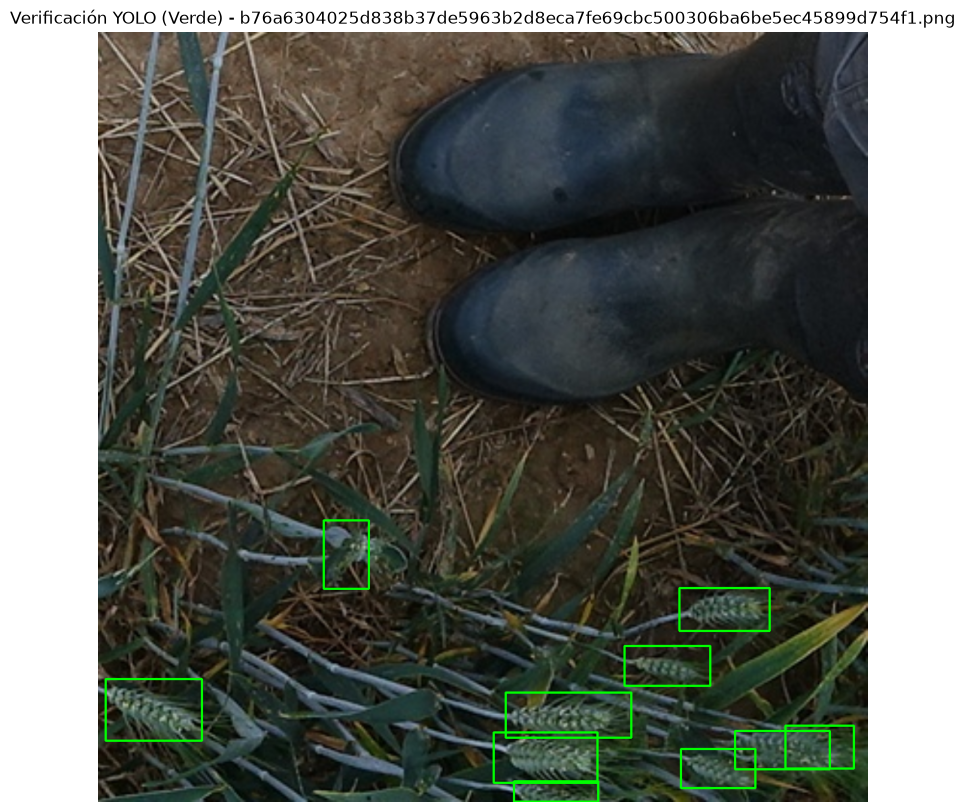

In [2]:
# Rutas a los datos procesados en YOLO
split = 'train'
yolo_img_dir = f'../data/processed/yolo/images/{split}'
yolo_lbl_dir = f'../data/processed/yolo/labels/{split}'

# Elegir una imagen al azar
images = [f for f in os.listdir(yolo_img_dir) if f.endswith('.png') or f.endswith('.jpg')]
img_name_yolo = random.choice(images)

img_path = os.path.join(yolo_img_dir, img_name_yolo)
lbl_path = os.path.join(yolo_lbl_dir, img_name_yolo.replace('.png', '.txt').replace('.jpg', '.txt'))

# Cargar la imagen
img_yolo = cv2.imread(img_path)
img_yolo = cv2.cvtColor(img_yolo, cv2.COLOR_BGR2RGB)
h, w, _ = img_yolo.shape

# Leer las etiquetas YOLO y dibujar (Color Verde)
if os.path.exists(lbl_path):
    with open(lbl_path, 'r') as f:
        for line in f.readlines():
            class_id, x_c, y_c, box_w, box_h = map(float, line.strip().split())
            
            # Desnormalizar
            x1 = int((x_c - box_w / 2) * w)
            y1 = int((y_c - box_h / 2) * h)
            x2 = int((x_c + box_w / 2) * w)
            y2 = int((y_c + box_h / 2) * h)
            
            cv2.rectangle(img_yolo, (x1, y1), (x2, y2), (0, 255, 0), 2)

plt.figure(figsize=(10, 10))
plt.imshow(img_yolo)
plt.title(f'Verificación YOLO (Verde) - {img_name_yolo}')
plt.axis('off')
plt.show()

## 2. Verificación del Formato COCO
Formato esperado en el `json`: un diccionario con listas de `images` y `annotations`, donde cada anotación contiene `bbox: [x_min, y_min, ancho, alto]` en píxeles absolutos.

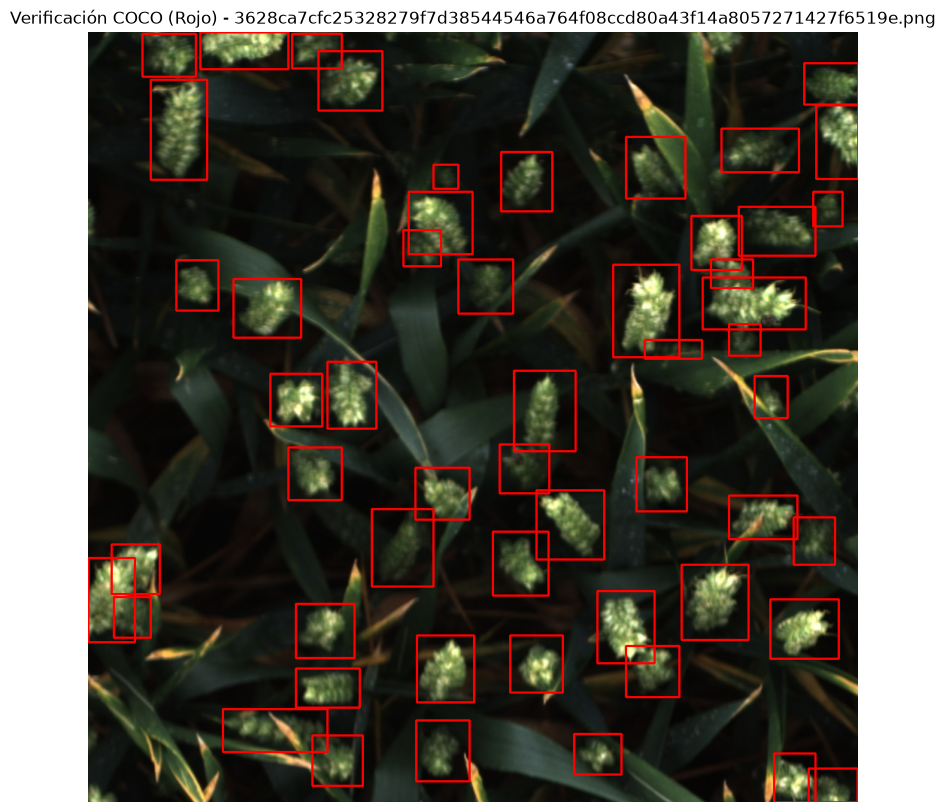

In [3]:
# Ruta al JSON de COCO y a las imágenes crudas
coco_json_path = f'../data/processed/coco/instances_{split}.json'
raw_img_dir = '../data/raw/images'

with open(coco_json_path, 'r') as f:
    coco_data = json.load(f)

# Elegir una imagen al azar de la metadata de COCO
coco_img_info = random.choice(coco_data['images'])
img_id = coco_img_info['id']
img_name_coco = coco_img_info['file_name']

# Cargar la imagen cruda
img_path_coco = os.path.join(raw_img_dir, img_name_coco)
img_coco = cv2.imread(img_path_coco)
img_coco = cv2.cvtColor(img_coco, cv2.COLOR_BGR2RGB)

# Filtrar anotaciones correspondientes a esta imagen
annotations = [ann for ann in coco_data['annotations'] if ann['image_id'] == img_id]

# Dibujar las etiquetas COCO (Color Rojo)
for ann in annotations:
    x_min, y_min, box_w, box_h = ann['bbox']
    
    # En COCO ya vienen en formato (x_min, y_min, ancho, alto) en píxeles, sin normalizar.
    x1 = int(x_min)
    y1 = int(y_min)
    x2 = int(x_min + box_w)
    y2 = int(y_min + box_h)
    
    cv2.rectangle(img_coco, (x1, y1), (x2, y2), (255, 0, 0), 2)

plt.figure(figsize=(10, 10))
plt.imshow(img_coco)
plt.title(f'Verificación COCO (Rojo) - {img_name_coco}')
plt.axis('off')
plt.show()